<a href="https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/11_reinforcement_learning_qlearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[⬅ Back to the course index](https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/00_START_HERE.ipynb) · **Notebook 11 of the course**


# 🩺 Notebook 11 — Reinforcement Learning for sepsis *(and why it doesn't work yet)*

> Every notebook so far **predicted** an outcome. This one is bolder: it tries to **choose the treatment**
> — how much fluid, how much vasopressor — to help a septic patient survive. We build a small "AI Clinician"
> (after Komorowski *et al.*, *Nature Medicine* 2018), **compare it to what real doctors did**, and then —
> the important part — **investigate, hands-on, why we can't trust it**.

**What you'll learn**
- How treatment becomes a **reinforcement-learning** problem (agent · state · action · reward), and why
  sepsis is **offline** RL (we can never experiment on patients).
- How to build a tiny AI-Clinician with **Q-learning** and read off what it recommends.
- How to **compare the AI to real clinicians** — and find they disagree a lot.
- 🔍 **Why it fails**, discovered from the data itself: the AI recommends treatments **almost nobody tried**,
  so its confidence is an illusion. We'll *prove* this and see the idea behind the modern fix.

**⏱️ Time:** ≈60 min · **Prerequisites:** Notebooks 01–06 · **Level:** advanced / bonus (but kept gentle)

### ▶️ Run me first
Same setup cell as every notebook — run it and move on.

In [ ]:
# === ⚙️  Workshop setup — run this cell first ===============================
# Works in Google Colab and in local Jupyter. Installs anything missing, sets a
# clean plotting style, and gives you helpers to load the data.
# (This cell is identical in every notebook of the course.)
import importlib.util, subprocess, sys, os, random, warnings
warnings.filterwarnings("ignore")

# --- reproducibility: everyone in the room gets the same numbers ---------------
RANDOM_STATE = 42
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)

# 📥 Where the workshop data comes from — already set up for you, nothing to do.
# The data downloads automatically the first time you need it. If you were given a
# different link, just paste it in place of the one below. These forms all work:
#   • a Google-Drive folder link      • a Drive / Dropbox / OneDrive file link
#   • a folder URL ending in "/"      • a link straight to a .zip
# Set it to "" if you would rather upload the CSVs by hand.
# (The data is not in the GitHub repo: it is real de-identified patient data covered
#  by a data use agreement and may not be redistributed openly.)
WORKSHOP_DATA_URL = os.environ.get(
    "WORKSHOP_DATA_URL",
    "https://drive.google.com/drive/folders/1y7CparhrqdlCAZq6xQlj8fZda394fniD")

def _ensure(pkgs):
    missing = [pip for mod, pip in pkgs.items() if importlib.util.find_spec(mod) is None]
    if missing:
        print("Installing:", *missing)
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing])
_ensure({"numpy":"numpy","pandas":"pandas","sklearn":"scikit-learn",
         "matplotlib":"matplotlib","seaborn":"seaborn","shap":"shap","xgboost":"xgboost"})

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
np.random.seed(RANDOM_STATE)          # seeds the legacy global np.random.* calls
RNG = np.random.default_rng(RANDOM_STATE)   # the modern generator — use this one
pd.set_option("display.max_columns", 120); pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5); plt.rcParams["figure.dpi"] = 110

# Every model, split and resample in this course passes random_state=RANDOM_STATE, so
# your numbers should match your neighbour's exactly. (Different library *versions* can
# still shift the last decimal — that is normal and not a mistake on your part.)

# --- data loading: works locally AND remembers your upload across notebooks -----
_CACHE = {"dir": "unset"}   # memo so we only touch Google Drive once per session

def _in_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except Exception:
        return False

def _drive_cache():
    """In Google Colab, mount Drive ONCE and return a persistent folder. A file you
    upload in one notebook is saved here, so every other notebook opens it automatically
    — no re-uploading. Returns None outside Colab, or if you decline to connect Drive."""
    if _CACHE["dir"] != "unset":
        return _CACHE["dir"]
    result = None
    if _in_colab():
        try:
            from google.colab import drive
            if not os.path.ismount("/content/drive"):
                drive.mount("/content/drive")
            result = "/content/drive/MyDrive/sepsis_workshop_data"
            os.makedirs(result, exist_ok=True)
        except Exception:
            result = None
    _CACHE["dir"] = result
    return result

def _find(name):
    """Look for the file on disk. Deliberately does NOT touch Google Drive, so the normal
    path never triggers an authorisation popup."""
    for p in [name, f"data/{name}", f"../data/{name}", f"workshop/data/{name}"]:
        if os.path.exists(p):
            return p
    return None

def _find_in_drive(name):
    """Only used as a fallback, because it mounts Drive (and that means a popup)."""
    cache = _drive_cache()
    if cache:
        p = os.path.join(cache, name)
        if os.path.exists(p):
            return p
    return None

def _direct_url(u):
    """Turn an ordinary Google-Drive / Dropbox / OneDrive *share* link into one that a
    plain HTTP client can actually download, so you can paste the link you were given."""
    import re
    m = (re.search(r"drive\.google\.com/file/d/([\w-]+)", u)
         or re.search(r"drive\.google\.com/(?:open|uc)\?(?:export=\w+&)?id=([\w-]+)", u))
    if m:
        return f"https://drive.google.com/uc?export=download&id={m.group(1)}"
    if "dropbox.com" in u:
        return u.split("?")[0] + "?dl=1"
    if "sharepoint.com" in u or "1drv.ms" in u:
        return u + ("&" if "?" in u else "?") + "download=1"
    return u

def _fetch(url, dest):
    import urllib.request, shutil as _sh
    req = urllib.request.Request(_direct_url(url), headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=120) as r, open(dest, "wb") as f:
        _sh.copyfileobj(r, f)

_FOLDER = {"done": False}

def _gdrive_folder(name):
    """WORKSHOP_DATA_URL points at a Google-Drive *folder*: fetch it once with gdown
    (a folder cannot be downloaded with a plain HTTP request), then serve files from it."""
    dest = "_workshop_data"
    if not _FOLDER["done"]:
        _ensure({"gdown": "gdown"})
        import gdown
        print("⬇  fetching the workshop data from Google Drive (just once) …")
        gdown.download_folder(url=WORKSHOP_DATA_URL, output=dest, quiet=True, use_cookies=False)
        _FOLDER["done"] = True
    for root, _dirs, files in os.walk(dest):
        if name in files:
            return os.path.join(root, name)
    return None

def _try_download(name):
    """Fetch the data from WORKSHOP_DATA_URL, if one was configured."""
    u = (WORKSHOP_DATA_URL or "").strip()
    if not u:
        return None
    try:
        if "/drive/folders/" in u:
            return _gdrive_folder(name)
        if u.lower().split("?")[0].endswith(".zip"):
            import zipfile
            bundle = "_workshop_data.zip"
            if not os.path.exists(bundle):
                print("⬇  downloading the workshop data bundle …")
                _fetch(u, bundle)
            with zipfile.ZipFile(bundle) as z:      # flatten any folder inside the zip
                for member in z.namelist():
                    if os.path.basename(member) == name:
                        with z.open(member) as src, open(name, "wb") as dst:
                            dst.write(src.read())
                        return name
            print(f"  ({name} was not inside the bundle)")
            return None
        print(f"⬇  downloading {name} …")
        _fetch(u.rstrip("/") + "/" + name, name)
        return name
    except Exception as e:
        print(f"  (download failed: {e})")
        for leftover in (name, "_workshop_data.zip"):
            if os.path.exists(leftover) and os.path.getsize(leftover) == 0:
                os.remove(leftover)
        return None

def _cache_to_drive(name, data):
    cache = _drive_cache()
    if cache:
        dest = os.path.join(cache, name)
        data.to_csv(dest, index=False)
        print(f"  💾 saved to Google Drive ({dest}) — no need to fetch it again.")

def load_csv(name):
    """Load a data CSV: looks on disk, then downloads it from WORKSHOP_DATA_URL, then checks
    your Google-Drive cache, and only as a last resort asks you to upload it — in which case
    it saves a copy to Drive so you never have to upload it twice."""
    p = _find(name)                       # 1. already on disk?
    if p:
        print(f"✓ loaded {p}")
        return pd.read_csv(p)
    p = _try_download(name)               # 2. the built-in download link
    if p:
        print(f"✓ loaded {name}")
        return pd.read_csv(p)
    p = _find_in_drive(name)              # 3. a copy you saved on a previous run
    if p:
        print(f"✓ loaded {p}")
        return pd.read_csv(p)
    try:                                  # 4. last resort: upload it by hand
        from google.colab import files
        print(f"⤴  Upload {name} just once — I'll save it so the other notebooks open it automatically:")
        up = files.upload()
        fname = list(up.keys())[0]
        data = pd.read_csv(fname)
        _cache_to_drive(name, data)
        return data
    except Exception:
        raise FileNotFoundError(
            f"Could not find {name}. Either paste your download link into WORKSHOP_DATA_URL at "
            f"the top of this cell, or put the CSV next to this notebook / in a data/ folder."
        )


In [2]:
# Tools we'll need, plus one reproducible random generator.
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")     # quiets a harmless Windows warning
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
rng = np.random.default_rng(RANDOM_STATE)

df = load_csv("sepsis_timeseries.csv")
df = df.sort_values(["icustayid", "bloc"]).reset_index(drop=True)   # RL needs events IN ORDER
print(f"{len(df):,} 4-hour blocks · {df['icustayid'].nunique():,} ICU stays")

✓ loaded data/sepsis_timeseries.csv
37,704 4-hour blocks · 1,696 ICU stays


## 🧭 What is reinforcement learning — in one picture

Notebooks 05–08 did **supervised learning**: *predict* who dies. The model was a bystander. Reinforcement
learning (RL) asks the harder question: **what should we DO to change the outcome?** It's a loop:

| RL term | Here (sepsis) |
|---|---|
| **Agent** | the treatment *policy* we're learning (an "AI clinician") |
| **Environment** | the *patient* |
| **State `s`** | the patient's condition this 4-h block (vitals, labs, scores) |
| **Action `a`** | the treatment: **fluid dose × vasopressor dose** |
| **Reward `r`** | **+100** if the patient survives to 90 days, **−100** if they die (given at the end) |
| **Policy `π(s)`** | the rule: *in this state, give this treatment* — what we learn |

**The catch: this is *offline* RL.** A game-playing agent learns by trying things and losing a million
games. We obviously can't do that to patients — so we learn only from **logged history**: what clinicians
did and what happened. That single constraint causes *every* problem in the second half of this notebook.

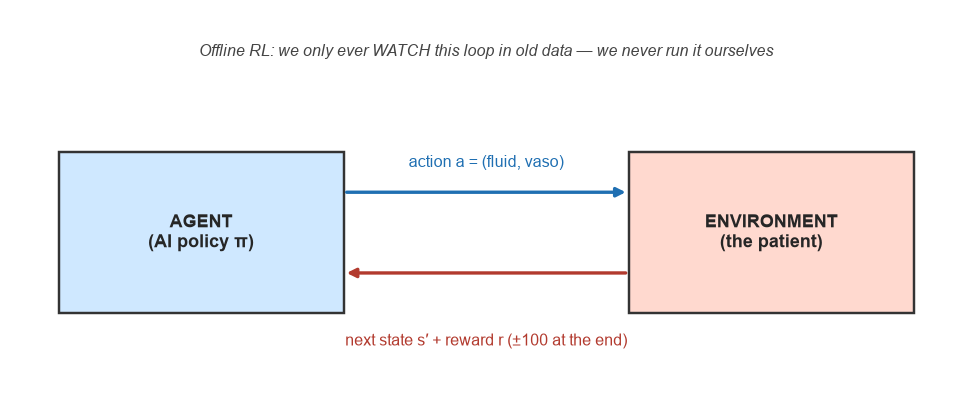

In [3]:
# A one-glance schematic of the agent–environment loop.
fig, ax = plt.subplots(figsize=(9, 3.8)); ax.axis("off")
def box(x, y, w, h, text, fc):
    ax.add_patch(plt.Rectangle((x, y), w, h, facecolor=fc, edgecolor="#333", lw=1.6))
    ax.text(x+w/2, y+h/2, text, ha="center", va="center", fontsize=12, weight="bold")
box(0.05, 0.35, 0.30, 0.32, "AGENT\n(AI policy π)", "#cfe8ff")
box(0.65, 0.35, 0.30, 0.32, "ENVIRONMENT\n(the patient)", "#ffd9cf")
ax.annotate("", xy=(0.65, 0.59), xytext=(0.35, 0.59), arrowprops=dict(arrowstyle="-|>", lw=2.2, color="#1f6fb2"))
ax.text(0.50, 0.64, "action a = (fluid, vaso)", ha="center", fontsize=10.5, color="#1f6fb2")
ax.annotate("", xy=(0.35, 0.43), xytext=(0.65, 0.43), arrowprops=dict(arrowstyle="-|>", lw=2.2, color="#b23a2e"))
ax.text(0.50, 0.31, "next state s′ + reward r (±100 at the end)", ha="center", va="top", fontsize=10.5, color="#b23a2e")
ax.text(0.50, 0.86, "Offline RL: we only ever WATCH this loop in old data — we never run it ourselves",
        ha="center", fontsize=10.5, style="italic", color="#444")
ax.set_xlim(0, 1); ax.set_ylim(0.2, 0.95); plt.tight_layout(); plt.show()

## 🧹 Step 1 — tidy the signals, then define the ACTIONS

First we winsorise the outlier-prone labs (clip to 1st–99th percentile, as in Notebook 02) so one typo
can't distort a whole group. Then we describe each block's treatment with **two dials** the bedside team
turns: **IV fluid** (`input_step`) and **vasopressor** (`max_dose_vaso`). We bin each into **5 levels**
(0 = none; positive doses split into quartiles), giving a **5 × 5 = 25-action** grid.

In [4]:
for c in ["Arterial_lactate", "Creatinine", "Shock_Index", "MeanBP", "HR"]:
    lo, hi = df[c].quantile([0.01, 0.99]); df[c] = df[c].clip(lo, hi)

def bin_5(series):
    x = series.to_numpy(float); out = np.zeros(len(x), int); pos = x > 0
    if pos.sum(): out[pos] = pd.qcut(x[pos], 4, labels=False, duplicates="drop") + 1
    return out
df["fluid_level"] = bin_5(df["input_step"])
df["vaso_level"]  = bin_5(df["max_dose_vaso"])
df["action"]      = df["fluid_level"] * 5 + df["vaso_level"]     # 0..24
print("Vasopressor levels used (0=none):", np.bincount(df["vaso_level"], minlength=5))
print("Fraction of blocks with NO vasopressor:", f"{(df['vaso_level']==0).mean():.0%}")

Vasopressor levels used (0=none): [31925  1542  1454  1389  1394]
Fraction of blocks with NO vasopressor: 85%


**What did the doctors actually do?** The heatmap counts how often each fluid × vaso combination was
chosen across all 37,704 decisions.

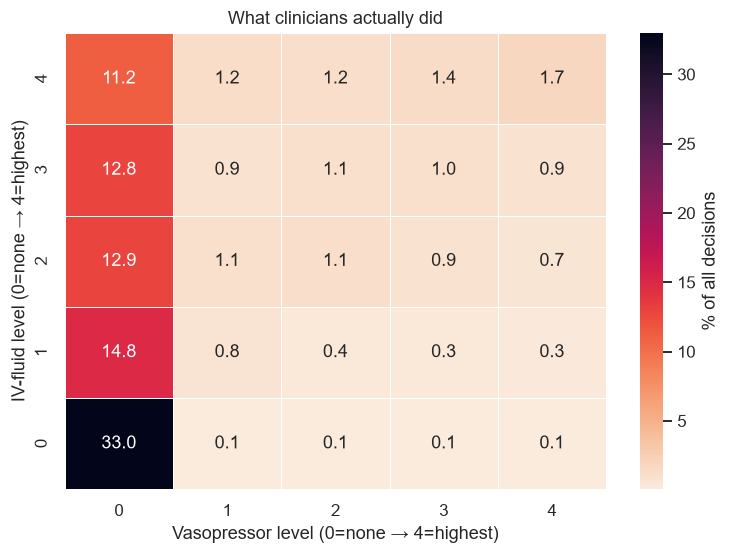

In [5]:
counts = (df.groupby(["fluid_level","vaso_level"]).size()
          .reindex(pd.MultiIndex.from_product([range(5),range(5)], names=["fluid_level","vaso_level"]), fill_value=0)
          .unstack("vaso_level"))
fig, ax = plt.subplots(figsize=(7, 5.2))
sns.heatmap(100*counts/counts.values.sum(), annot=True, fmt=".1f", cmap="rocket_r",
            cbar_kws={"label": "% of all decisions"}, linewidths=.5, linecolor="white", ax=ax)
ax.set_xlabel("Vasopressor level (0=none → 4=highest)"); ax.set_ylabel("IV-fluid level (0=none → 4=highest)")
ax.invert_yaxis(); ax.set_title("What clinicians actually did"); plt.tight_layout(); plt.show()

> 🧠 **Remember this.** Real care piles up in the **left column** (no vasopressor) — pressors are held back
> for shock. So the top-right actions (lots of both) were **almost never tried**. Keep an eye on those
> nearly-empty cells: the agent will still form an opinion about them, with *no evidence* to back it up.

## 🩻 Step 2 — describe the patient's STATE (100 groups)

A "state" answers *"how is this patient doing right now?"* We take **9 everyday signals** — `SOFA`, `SIRS`,
lactate, `MeanBP`, `HR`, creatinine, `GCS`, shock index, age — and, because Q-learning needs a *finite* list
of states, we cluster patients into **100 groups** with K-means. Each group = "a recognisable kind of septic
patient." We add two final **terminal** states, `SURVIVE` and `DIE`, that a stay ends in.

*(We use 100 groups to keep things simple and give each group more data. Fewer groups = coarser but
better-supported; more groups = finer but noisier. You'll feel this trade-off in the exercises.)*

In [6]:
FEATURES = ["SOFA","SIRS","Arterial_lactate","MeanBP","HR","Creatinine","GCS","Shock_Index","age"]
N = 100                                       # number of patient-state clusters
Xs = StandardScaler().fit_transform(SimpleImputer(strategy="median").fit_transform(df[FEATURES]))
df["state"] = KMeans(N, random_state=RANDOM_STATE, n_init=3, max_iter=100).fit_predict(Xs)
SURVIVE, DIE = N, N + 1
sizes = np.bincount(df["state"], minlength=N)
print(f"{N} patient-state groups + 2 terminals.  Blocks per group: "
      f"min {sizes.min()}, median {int(np.median(sizes))}, max {sizes.max()}")

100 patient-state groups + 2 terminals.  Blocks per group: min 111, median 368, max 749


## 🔗 Step 3 — trajectories become transitions `(s, a, r, s′)`

RL learns from **transitions**: *in state `s` we gave treatment `a`, then the patient moved to `s′`.* Within a
stay, each block flows to the next with reward 0. At the **last** block the patient exits to `SURVIVE` or `DIE`
and the reward lands: **+100** or **−100**. (Sparse, terminal-only reward = "we only care about the final
outcome; figure out for yourself which states were on the road to a good one.")

In [7]:
nxt   = df.groupby("icustayid")["state"].shift(-1)
nxt_a = df.groupby("icustayid")["action"].shift(-1)
is_last = nxt.isna().to_numpy(); died = df["morta_90"].to_numpy()
s      = df["state"].to_numpy()
a      = df["action"].to_numpy()
s_next = np.where(is_last, np.where(died==1, DIE, SURVIVE), nxt.to_numpy()).astype(int)
reward = np.where(is_last, np.where(died==1, -100., 100.), 0.).astype(float)
done   = is_last.astype(float)
next_a = np.where(is_last, 0, np.nan_to_num(nxt_a.to_numpy())).astype(int)
print(f"{len(s):,} transitions ({int(done.sum()):,} terminal).")

37,704 transitions (1,696 terminal).


## 🎓 Step 4 — learn the table `Q[s, a]` with Q-learning

`Q[s, a]` = *"how good is giving treatment `a` in state `s`, if we act well afterwards?"* Starting from zeros,
we nudge it toward the **Bellman target** — the reward now, plus the best value we can reach next:

$$Q[s,a] \;\leftarrow\; Q[s,a] + \alpha\,\big(\,r + \gamma\,\max_{a'} Q[s',a'] - Q[s,a]\,\big)$$

with discount **γ = 0.99**. That `max` over next actions is the **off-policy** heart of Q-learning: the agent
bootstraps toward the *best* next move — *even one no clinician ever tried.* (Hold that thought.) We run it as
a fast, deterministic batch sweep.

In [8]:
def q_learn(reward, s_next, done, gamma=0.99, n_epochs=50, n_actions=25):
    Q = np.zeros((N + 2, n_actions)); v_curve, u_curve = [], []
    for e in range(n_epochs):
        alpha = 0.5 * (0.93 ** e) + 0.02
        target = reward + gamma * (1 - done) * Q[s_next].max(1)     # Bellman target
        td = target - Q[s, a]
        sum_td = np.zeros_like(Q); cnt = np.zeros_like(Q)
        np.add.at(sum_td, (s, a), td); np.add.at(cnt, (s, a), 1.)
        upd = alpha * np.where(cnt > 0, sum_td / np.maximum(cnt, 1), 0.)
        Q += upd
        u_curve.append(np.abs(upd[cnt > 0]).mean()); v_curve.append(Q[:N].max(1).mean())
    return Q, np.array(u_curve), np.array(v_curve)

GAMMA = 0.99
Q, u_curve, v_curve = q_learn(reward, s_next, done, gamma=GAMMA)
print(f"Trained. Mean learned state-value ≈ {v_curve[-1]:.0f} (out of a possible +100).")

Trained. Mean learned state-value ≈ 89 (out of a possible +100).


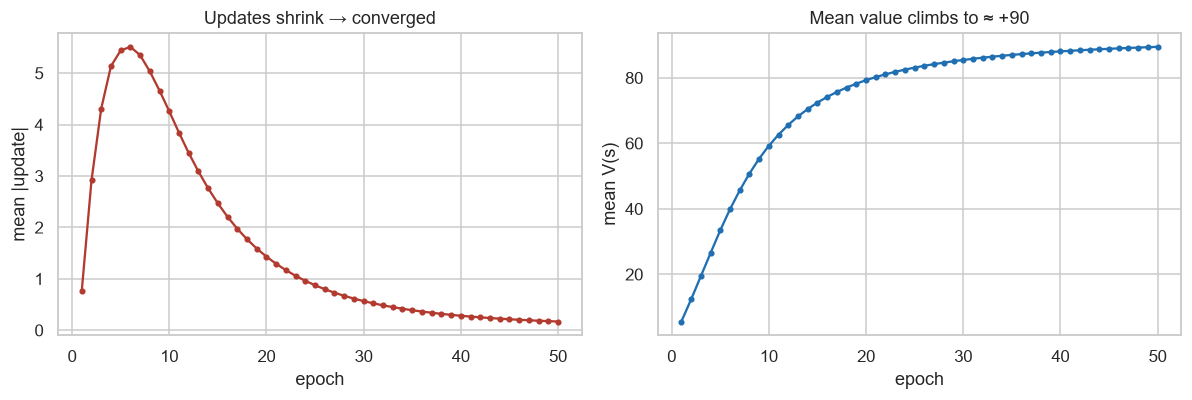

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(range(1, len(u_curve)+1), u_curve, "-o", ms=3, color="#b23a2e")
ax[0].set_title("Updates shrink → converged"); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("mean |update|")
ax[1].plot(range(1, len(v_curve)+1), v_curve, "-o", ms=3, color="#1f6fb2")
ax[1].set_title("Mean value climbs to ≈ +90"); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("mean V(s)")
plt.tight_layout(); plt.show()

> 🧠 That mean value **≈ +90** already looks *too good* — it says the agent believes almost every patient
> can be steered to survival. That over-confidence is the first clue. Let's read the policy, then hunt it down.

## 💊 Step 5 — the learned policy, and does it look like medicine?

The policy is just *"in each state, take the highest-Q action."* We decode it into a recommended vaso level
and plot it across two axes any doctor reads instantly: **lactate** (higher = sicker) and **mean arterial
pressure** (lower = sicker). A sensible policy should give **more pressor when blood pressure is low**.

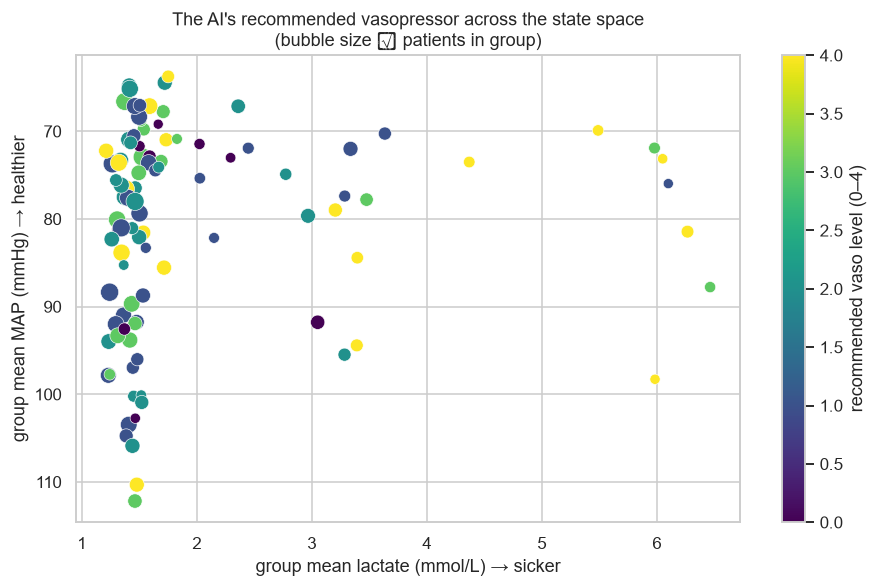

In [10]:
policy    = Q[:N].argmax(1)
rec_vaso  = policy % 5
rec_fluid = policy // 5

cl = df.groupby("state").agg(lactate=("Arterial_lactate","mean"), meanbp=("MeanBP","mean"), size=("state","size"))
cl["rec_vaso"] = rec_vaso[cl.index.to_numpy()]
fig, ax = plt.subplots(figsize=(8.5, 5.5))
sc = ax.scatter(cl["lactate"], cl["meanbp"], c=cl["rec_vaso"], s=25 + cl["size"]/6,
                cmap="viridis", vmin=0, vmax=4, edgecolor="white", linewidth=.4)
ax.set_xlabel("group mean lactate (mmol/L) → sicker"); ax.set_ylabel("group mean MAP (mmHg) → healthier")
ax.invert_yaxis(); plt.colorbar(sc, label="recommended vaso level (0–4)")
ax.set_title("The AI's recommended vasopressor across the state space\n(bubble size ∝ patients in group)")
plt.tight_layout(); plt.show()

> 🧠 **Honest read.** Down the **blood-pressure** axis it's coherent — more pressor when MAP is low (top). But
> the recommendations are also **jumpy and extreme**, and along lactate they barely make sense. Something is
> off. Time to compare with real doctors and find out what.

## ⚖️ Step 6 — compare the AI to real clinicians

For each state, does the AI recommend **more, the same, or less** vasopressor than clinicians actually gave?
And does its single best action ever match the doctors' **most common** action there?

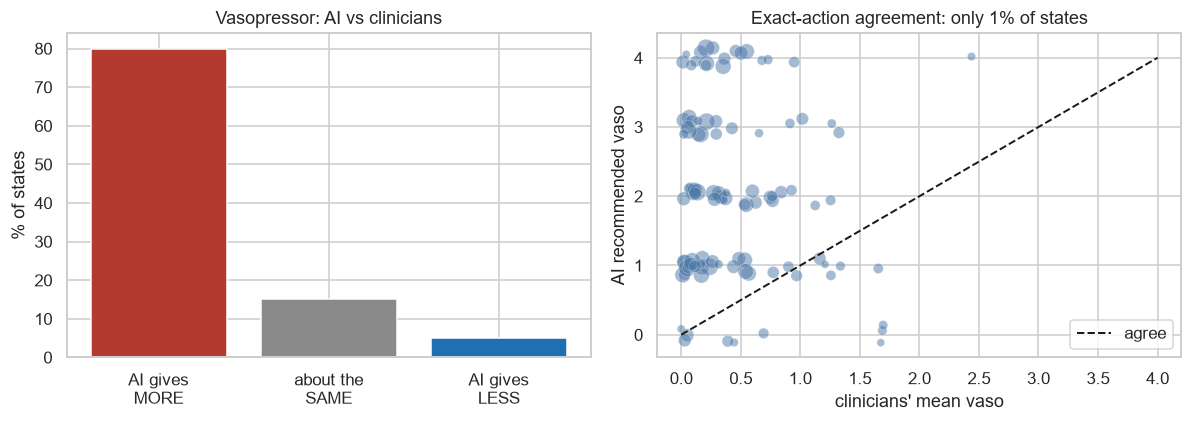

AI recommends MORE vaso in 80% of states; matches doctors' usual action in just 1%.


In [11]:
clin_vaso  = df.groupby("state")["vaso_level"].mean().reindex(range(N))
support    = np.zeros((N, 25), int); np.add.at(support, (s, a), 1)   # times each (state,action) was seen
clin_modal = support.argmax(1)                                       # doctors' most common action per state

more = (rec_vaso > clin_vaso + 0.5); less = (rec_vaso < clin_vaso - 0.5); same = ~(more | less)
agree = (policy == clin_modal).mean()

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].bar(["AI gives\nMORE","about the\nSAME","AI gives\nLESS"], [100*more.mean(),100*same.mean(),100*less.mean()],
          color=["#b23a2e","#8a8a8a","#1f6fb2"], edgecolor="white")
ax[0].set_ylabel("% of states"); ax[0].set_title("Vasopressor: AI vs clinicians")
ax[1].scatter(clin_vaso, rec_vaso + rng.uniform(-.15,.15,N), s=8+sizes/6, alpha=.5, color="#4c78a8", edgecolor="white", lw=.3)
ax[1].plot([0,4],[0,4],"k--",lw=1.3,label="agree"); ax[1].set_xlabel("clinicians' mean vaso"); ax[1].set_ylabel("AI recommended vaso")
ax[1].legend(); ax[1].set_title(f"Exact-action agreement: only {agree:.0%} of states")
plt.tight_layout(); plt.show()
print(f"AI recommends MORE vaso in {more.mean():.0%} of states; matches doctors' usual action in just {agree:.0%}.")

> 🧠 The AI wants **more, earlier vasopressors** almost everywhere, and it hardly ever picks the doctors'
> usual choice. That echoes a real (and hotly debated) claim from the original AI Clinician paper. But before
> we get excited — *is the AI seeing something doctors miss, or is it just making things up?* Let's check.

## 🔍 Step 7 — **why doesn't it work?** Follow the data

Here's the test that settles it. When the AI recommends an action for a state, **how many times was that
exact action actually tried in that state?** If the answer is "almost never," the recommendation is a guess
with no evidence — and the `max` in Q-learning will have made that guess look *great*.

AI's recommended action was actually tried a MEDIAN of 2 times in its state.
   → in 83/100 states the recommended action was seen fewer than 5 times.
Doctors' usual action, by contrast, has a median of 117 observations.


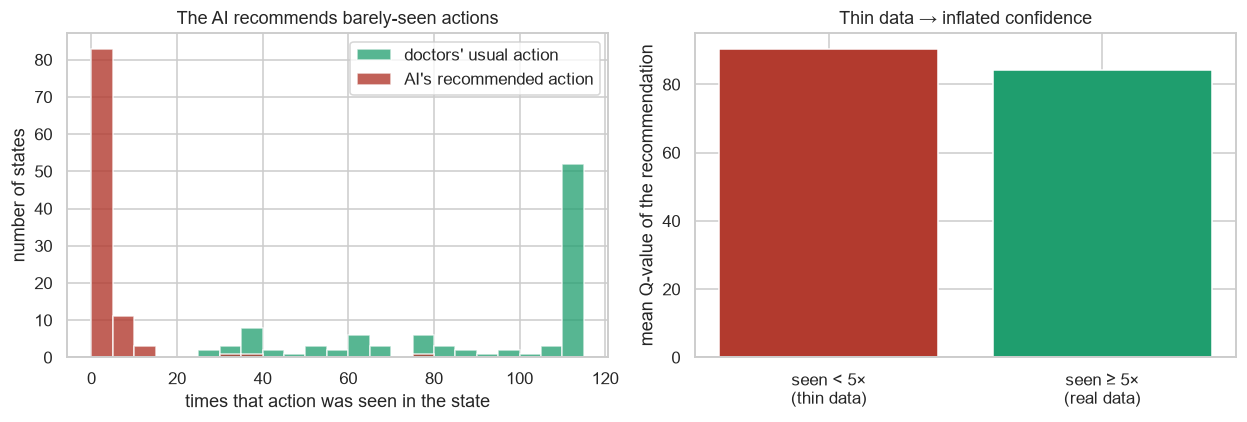

In [12]:
rec_support  = support[np.arange(N), policy]                 # data behind the AI's choice, per state
clin_support = support[np.arange(N), clin_modal]              # data behind the doctors' usual choice

print(f"AI's recommended action was actually tried a MEDIAN of {int(np.median(rec_support))} times in its state.")
print(f"   → in {(rec_support < 5).sum()}/{N} states the recommended action was seen fewer than 5 times.")
print(f"Doctors' usual action, by contrast, has a median of {int(np.median(clin_support))} observations.")

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4))
bins = np.arange(0, 120, 5)
ax[0].hist(np.clip(clin_support,0,115), bins=bins, alpha=.75, label="doctors' usual action", color="#1f9e6e")
ax[0].hist(np.clip(rec_support,0,115),  bins=bins, alpha=.8,  label="AI's recommended action", color="#b23a2e")
ax[0].set_xlabel("times that action was seen in the state"); ax[0].set_ylabel("number of states")
ax[0].set_title("The AI recommends barely-seen actions"); ax[0].legend()
# over-optimism: thin data → higher (inflated) Q
recQ = Q[np.arange(N), policy]; low = rec_support < 5
ax[1].bar(["seen < 5×\n(thin data)","seen ≥ 5×\n(real data)"], [recQ[low].mean(), recQ[~low].mean()],
          color=["#b23a2e","#1f9e6e"], edgecolor="white")
ax[1].set_ylabel("mean Q-value of the recommendation"); ax[1].set_title("Thin data → inflated confidence")
plt.tight_layout(); plt.show()

So the AI's boldest advice sits on the **thinnest evidence**, and those thin-data choices carry the
**highest** Q-values. Let's confirm this is what drives the "give more vasopressor" headline:

In [13]:
more_on_thin = (more.to_numpy() & (rec_support < 5)).sum() / max(more.sum(), 1)
print(f"Of the states where the AI wants MORE vasopressor, {more_on_thin:.0%} rest on an action seen < 5 times.")
print("→ The exciting 'AI would give more pressors' finding is largely the model extrapolating into")
print("  treatment combinations doctors almost never chose — where it has no way to actually know.")

Of the states where the AI wants MORE vasopressor, 91% rest on an action seen < 5 times.
→ The exciting 'AI would give more pressors' finding is largely the model extrapolating into
  treatment combinations doctors almost never chose — where it has no way to actually know.


### 🧪 The clincher: forbid the guesses, and the AI calms down

If the problem really is *recommending unseen actions*, then **restricting the AI to actions with enough
support** should fix most of it. This is a poor-man's version of modern offline-RL methods (**BCQ**, **CQL**)
that are built to distrust unsupported actions. We only let the policy choose actions seen **≥ 5 times** in
that state.

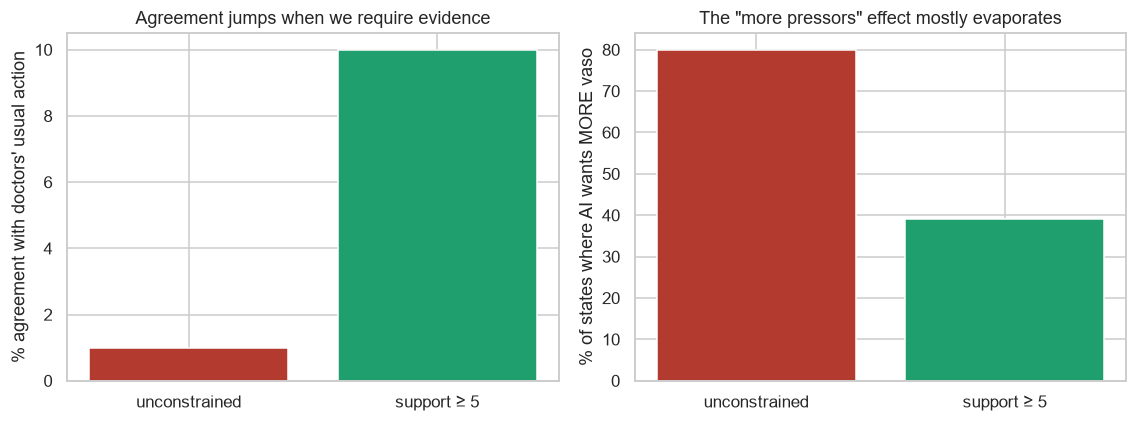

Requiring evidence changed 83% of recommendations.
Agreement with doctors: 1% → 10%.   'AI wants more vaso': 80% → 39%.


In [14]:
K = 5
Qc = Q[:N].copy(); Qc[support < K] = -1e9          # ban actions with < K observations in the state
no_support = (support < K).all(1)                   # a few states have no well-seen action...
constrained = Qc.argmax(1); constrained[no_support] = clin_modal[no_support]   # ...fall back to doctors
c_vaso = constrained % 5
c_more = (pd.Series(c_vaso, index=range(N)) > clin_vaso + 0.5).mean()
c_agree = (constrained == clin_modal).mean()

fig, ax = plt.subplots(1, 2, figsize=(10.5, 4))
ax[0].bar(["unconstrained","support ≥ 5"], [100*agree, 100*c_agree], color=["#b23a2e","#1f9e6e"], edgecolor="white")
ax[0].set_ylabel("% agreement with doctors' usual action"); ax[0].set_title("Agreement jumps when we require evidence")
ax[1].bar(["unconstrained","support ≥ 5"], [100*more.mean(), 100*c_more], color=["#b23a2e","#1f9e6e"], edgecolor="white")
ax[1].set_ylabel('% of states where AI wants MORE vaso'); ax[1].set_title('The "more pressors" effect mostly evaporates')
plt.tight_layout(); plt.show()
print(f"Requiring evidence changed {(constrained!=policy).mean():.0%} of recommendations.")
print(f"Agreement with doctors: {agree:.0%} → {c_agree:.0%}.   'AI wants more vaso': {more.mean():.0%} → {c_more:.0%}.")

> 🧠 **This is the whole lesson.** The instant we stop the agent from prescribing treatments it never really
> saw, it stops hallucinating and starts to look like a **cautious clinician**. The original policy didn't
> discover better medicine — it exploited **gaps in the data**. Distrusting unsupported actions is exactly the
> idea behind the offline-RL algorithms (BCQ, CQL) you'd use for real work.

## 📉 Step 8 — one more mirror: value over-estimation

A last sanity check. If the learned values are meaningful, patients who **survived** should have started in
**higher-value** states. We compare two "values" at each patient's **first block**: `V*` under the AI's
optimal policy (the `max`), and `V_clin` under the **clinicians' own** actions (bootstrapping on what they
actually did next — an on-policy / SARSA estimate).

          V* (AI optimal)  V_clin (doctors)
outcome                                    
died                 88.8              47.3
survived             89.1              51.5


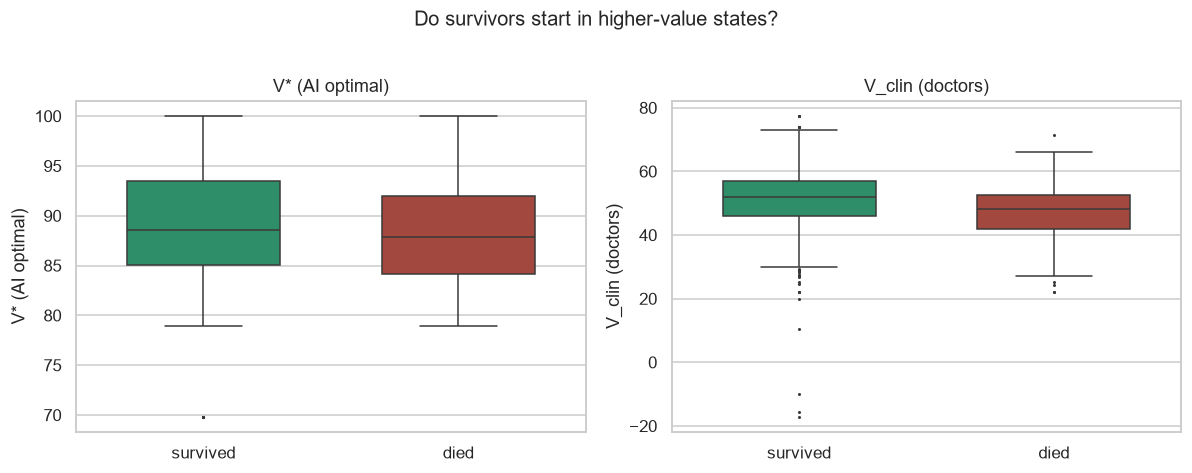

In [15]:
def sarsa(gamma=0.99, n_epochs=60):
    Q = np.zeros((N + 2, 25))
    for _ in range(n_epochs):
        target = reward + gamma * (1 - done) * Q[s_next, next_a]     # bootstrap on the ACTUAL next action
        td = target - Q[s, a]; sum_td = np.zeros_like(Q); cnt = np.zeros_like(Q)
        np.add.at(sum_td, (s, a), td); np.add.at(cnt, (s, a), 1.); Q += np.where(cnt>0, sum_td/np.maximum(cnt,1), 0.)
    return Q
Q_clin = sarsa(gamma=GAMMA)
first = df.groupby("icustayid").head(1)
s0, a0, died0 = first["state"].to_numpy(), first["action"].to_numpy(), first["morta_90"].to_numpy()
val = pd.DataFrame({"outcome": np.where(died0==1, "died", "survived"),
                    "V* (AI optimal)": Q[s0].max(1), "V_clin (doctors)": Q_clin[s0, a0]})
print(val.groupby("outcome").mean().round(1))
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2)); pal={"survived":"#1f9e6e","died":"#b23a2e"}
for a_, col in zip(ax, ["V* (AI optimal)", "V_clin (doctors)"]):
    sns.boxplot(data=val, x="outcome", y=col, order=["survived","died"], hue="outcome", palette=pal,
                legend=False, ax=a_, width=.6, fliersize=1); a_.set_xlabel(""); a_.set_title(col)
fig.suptitle("Do survivors start in higher-value states?", y=1.02, fontsize=13); plt.tight_layout(); plt.show()

> 🧠 Under the **doctors'** policy (right) survivors clearly start higher than non-survivors — the values are
> *coherent*. Under the AI's **optimal** policy (left) the two groups are almost **identical and both pinned
> near +100**: the `max` has convinced the agent nearly everyone can be saved. That gap is **off-policy value
> over-estimation** — and it's why a great-looking learned value is **not** evidence the policy works.

## ⚠️ So — can we use this at the bedside? **No.** Here's why, in full

We just built something that *looks* like an AI that treats sepsis, and we watched it fail three ways. The
underlying reasons matter:

**1. Off-policy evaluation is genuinely hard.** Our policy recommends *different* actions than were taken, so
we never observe what would have happened. Estimating the value of a policy you didn't run is the central,
unsolved-in-practice problem of offline RL. The honest tools are all imperfect: **importance sampling
(IS/WIS)** — variance explodes when policies disagree (our case); **Fitted Q Evaluation (FQE)** — only as good
as its own extrapolation. Each can report a confident number that's simply wrong.

**2. Distribution shift & "dead ends."** As we *proved above*, the agent assigns high value to `(state,
action)` pairs it barely saw. With a `max` in the update, unseen actions can look **optimistically great** with
no evidence — and the policy then prefers them.

**3. Reward mis-specification.** Our reward is **+100 survive / −100 die and nothing else** — blind to
bleeding, limb ischaemia from pressors, fluid overload, quality of life. Optimise a narrow proxy, get a policy
that games it.

**4. Tiny, single-centre, discretised data.** ~1,700 down-sampled stays, 100 states, 25 actions. Real
AI-Clinician-scale work uses tens of thousands of patients and *still* draws serious methodological fire.

**5. Ethics.** A wrong *prediction* costs a little trust; a wrong *prescription* can cost a life. Bedside RL
demands prospective validation, rigorous uncertainty-aware evaluation, human oversight, and ultimately
randomised trials.

**📚 Read both sides**
- Komorowski M, Celi LA, Badawi O, Gordon AC, Faisal AA. *The Artificial Intelligence Clinician learns optimal
  treatment strategies for sepsis in intensive care.* **Nature Medicine** 24, 1716–1720 (2018).
- Gottesman O, Johansson F, Komorowski M, *et al.* *Guidelines for reinforcement learning in healthcare.*
  **Nature Medicine** 25, 16–18 (2019) — a clear catalogue of exactly these pitfalls.

> 🧠 **Bottom line.** This notebook is a **thinking tool** for RL intuition, *not* a treatment policy. The
> supervised models of Notebooks 05–08 remain the honest, evaluable baseline. When an RL policy claims to beat
> clinicians, the right reflex is *"show me the data support and the off-policy evaluation."*

## ✏️ Your turn

### Exercise 1 — Raise the evidence bar
Re-run the support-constrained policy with **K = 20** (an action must be seen ≥ 20 times). Does agreement with
doctors rise further? How many states fall back to the clinician default?

In [16]:
# TODO: copy the K=5 cell, set K=20, and print agreement + how many states hit `no_support`.


<details><summary>💡 Show solution</summary>

```python
K = 20
Qc = Q[:N].copy(); Qc[support < K] = -1e9
no_support = (support < K).all(1)
constrained20 = Qc.argmax(1); constrained20[no_support] = clin_modal[no_support]
print(f"K=20 → agreement {(constrained20==clin_modal).mean():.0%}, "
      f"{no_support.sum()}/{N} states fall back to the doctor default")
# Stricter support → closer to clinicians, but more states have no well-seen alternative at all,
# so the 'AI' increasingly just copies the doctors. That tension (evidence vs. originality) is the
# core design problem of offline RL.
```
</details>

### Exercise 2 — Does the discount γ change the story?
Re-train with **γ = 0.90** (more short-sighted) using the same transitions, and check whether the coverage
problem (median support of the recommended action) is any better. *(Hint: it isn't — the problem is the
data, not γ.)*

In [17]:
# TODO: Q90,_,_ = q_learn(reward, s_next, done, gamma=0.90); decode its policy; median support of its rec action.


<details><summary>💡 Show solution</summary>

```python
Q90, _, _ = q_learn(reward, s_next, done, gamma=0.90)
pol90 = Q90[:N].argmax(1)
print("median support of recommended action:  γ=0.99 →",
      int(np.median(support[np.arange(N), policy])), " | γ=0.90 →",
      int(np.median(support[np.arange(N), pol90])))
# γ changes how far ahead the agent looks, and flips some recommendations — but the recommended
# actions are still barely-seen. No discount can conjure evidence that isn't in the data.
```
</details>

## ✅ Recap
- We framed sepsis care as **offline RL** and built a tiny **Q-learning** AI Clinician (5×5 actions, 100
  patient-state groups, ±100 terminal reward).
- Compared to real doctors, it wanted **more/earlier vasopressors** (80% of states) and matched their usual
  action just **1%** of the time.
- 🔍 **We found out why:** its recommended actions were seen a **median of ~2 times** — it prescribes
  treatments almost nobody tried, and the `max` makes those guesses look *best*. Restricting it to
  **well-supported actions** made it behave like a cautious clinician — the idea behind **BCQ / CQL**.
- A value check exposed **off-policy over-estimation** (V\* fails to separate outcomes; the doctors' value
  separates cleanly).
- **None of this is evidence the policy saves lives** — that needs support-aware methods, honest off-policy
  evaluation, and ultimately trials.

## ➡️ Next — going further (responsibly)
- **Offline-RL algorithms that distrust unseen actions:** Conservative Q-Learning (**CQL**), Batch-Constrained
  Q-learning (**BCQ**) — the grown-up version of our support constraint.
- **Honest evaluation:** Fitted Q Evaluation (**FQE**), weighted importance sampling with **confidence
  intervals** — never a single point estimate.
- **Tooling:** [`d3rlpy`](https://github.com/takuseno/d3rlpy) implements CQL/BCQ/FQE on datasets like this.
- The trustworthy path to helping patients runs **through** the supervised, evaluable baselines of Notebooks
  05–08 — not around them.

> 🎓 **You've finished the course.** You can clean messy clinical time series, engineer leakage-safe features,
> build and *honestly* evaluate models, explain them, and reason about the promise **and perils** of
> prescriptive AI. That last skill — measured skepticism, backed by checking the data — is the one to keep.